# Проект: A/B-тестирование оптимизации кредитной анкеты

### Описание эксперимента
Мы проводим A/B-тестирование двух вариантов дизайна интерфейса кредитной анкеты. 
* **Группа A (Control):** Текущая версия анкеты.
* **Группа B (Test):** Новый, упрощенный и интуитивно понятный дизайн интерфейса.

### Метрики эффективности
1. **Primary (Основная метрика):** `time_to_complete` — время заполнения анкеты (в секундах). Наша цель — сократить время прохождения формы.
2. **Secondary (Вспомогательная метрика):** `is_submitted` — конверсия в успешную отправку анкеты (бинарный флаг: 1 — отправлено, 0 — отток). Цель — увеличить или удержать конверсию.
3. **Guardrail (Бизнес-ограничение):** `is_bad` — уровень жесткой просрочки (дефолтность). Мы должны убедиться, что упрощение анкеты не ухудшило качество входящего потока клиентов (метрика не должна значимо вырасти).

### Гипотезы
* $H_0$ (Нулевая гипотеза): Новый дизайн интерфейса не влияет на метрики (среднее время, конверсия и риски в группах одинаковы).
* $H_1$ (Альтернативная гипотеза): Новый дизайн значимо сокращает время заполнения, меняет конверсию или влияет на уровень рисков.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rikdifos/credit-card-approval-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\rikdifos\credit-card-approval-prediction\versions\3


In [2]:
import pandas as pd
import numpy as np

import pingouin as pg

import seaborn as sns
import matplotlib.pyplot as plt

import os

## 1. Загрузка и предпросмотр данных

In [3]:
files = os.listdir(path)
print("")
for i in files:
    print(i)


application_record.csv
credit_record.csv


In [4]:
app_df = pd.read_csv(os.path.join(path, 'application_record.csv'))
credit_df = pd.read_csv(os.path.join(path, 'credit_record.csv'))

In [5]:
app_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [6]:
# Перевод названий колонок в нижний регистр
app_df.columns = app_df.columns.str.lower()

In [7]:
app_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   438557 non-null  int64  
 1   code_gender          438557 non-null  object 
 2   flag_own_car         438557 non-null  object 
 3   flag_own_realty      438557 non-null  object 
 4   cnt_children         438557 non-null  int64  
 5   amt_income_total     438557 non-null  float64
 6   name_income_type     438557 non-null  object 
 7   name_education_type  438557 non-null  object 
 8   name_family_status   438557 non-null  object 
 9   name_housing_type    438557 non-null  object 
 10  days_birth           438557 non-null  int64  
 11  days_employed        438557 non-null  int64  
 12  flag_mobil           438557 non-null  int64  
 13  flag_work_phone      438557 non-null  int64  
 14  flag_phone           438557 non-null  int64  
 15  flag_email       

In [8]:
print(f"Полных дубликатов: {app_df.duplicated().sum()}")
print(f"Дубликаты в ID: {app_df['id'].duplicated().sum()}")
print(f"Пропуски:\n{app_df.isna().sum()}")

Полных дубликатов: 0
Дубликаты в ID: 47
Пропуски:
id                          0
code_gender                 0
flag_own_car                0
flag_own_realty             0
cnt_children                0
amt_income_total            0
name_income_type            0
name_education_type         0
name_family_status          0
name_housing_type           0
days_birth                  0
days_employed               0
flag_mobil                  0
flag_work_phone             0
flag_phone                  0
flag_email                  0
occupation_type        134203
cnt_fam_members             0
dtype: int64


In [9]:
credit_df.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [10]:
# Перевод названий колонок в нижний регистр
credit_df.columns = credit_df.columns.str.lower()

In [11]:
credit_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   id              1048575 non-null  int64 
 1   months_balance  1048575 non-null  int64 
 2   status          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


In [12]:
print(f"Полных дубликатов: {credit_df.duplicated().sum()}")
print(f"Дубликаты в ID: {credit_df['id'].duplicated().sum()}")
print(f"Пропуски:\n{credit_df.isna().sum()}")

Полных дубликатов: 0
Дубликаты в ID: 1002590
Пропуски:
id                0
months_balance    0
status            0
dtype: int64


In [13]:
# Удаляем дубликаты в app_df по колонке id
app_clean = app_df.drop_duplicates(subset='id', keep='last')

In [14]:
# Создаем признак жесткой просрочки: 1 если статус от 2 до 5, иначе 0
credit_df['is_bad'] = credit_df['status'].isin(['2', '3', '4', '5']).astype(int)

# Группируем по id и находим, был ли у клиента хотя бы один факт жесткой просрочки
user_risk = credit_df.groupby('id')['is_bad'].max().reset_index()

In [15]:
df_base = pd.merge(app_clean, user_risk, how='left', on='id')

In [16]:
df_base['is_bad'] = df_base['is_bad'].fillna(0)

In [17]:
print(f"Количество надежных и рисковых клиентов: {df_base['is_bad'].value_counts()}")

Количество надежных и рисковых клиентов: is_bad
0.0    437894
1.0       616
Name: count, dtype: int64


## 2. Симуляция данных A/B-теста

In [18]:
np.random.seed(42)
df_base['variant'] = np.random.choice(['A', 'B'], size=len(df_base))
df_base['variant'].value_counts()

variant
B    219417
A    219093
Name: count, dtype: int64

In [19]:
np.random.seed(42)
# Генерируем случайное число для каждого пользователя от 0 до 1
random_probs = np.random.rand(len(df_base))

# Если группа А, то конверсия 70% (random_probs < 0.70). Если B — 75% (random_probs < 0.75)
df_base['is_submitted'] = np.where(
    df_base['variant'] == 'A',
    (random_probs < 0.70).astype(int),
    (random_probs < 0.75).astype(int)
)

In [20]:
df_base.groupby('variant')['is_submitted'].mean()

variant
A    0.700483
B    0.749668
Name: is_submitted, dtype: float64

In [21]:
df_base['time_to_complete'] = np.nan

In [22]:
np.random.seed(42)
# Считаем, сколько человек в группе А отправили анкету
size_a = ((df_base['variant'] == 'A') & (df_base['is_submitted'] == 1)).sum()

# Записываем им случайное время со средним 180 секунд
df_base.loc[(df_base['variant'] == 'A') & (df_base['is_submitted'] == 1), 'time_to_complete'] = \
    np.random.normal(loc=180, scale=30, size=size_a)

In [23]:
np.random.seed(42)
# Считаем, сколько человек в группе B отправили анкету
size_b = ((df_base['variant'] == 'B') & (df_base['is_submitted'] == 1)).sum()

# Записываем им случайное время со средним 120 секунд
df_base.loc[(df_base['variant'] == 'B') & (df_base['is_submitted'] == 1), 'time_to_complete'] = \
    np.random.normal(loc=120, scale=20, size=size_b)

In [24]:
df_base.groupby('variant')['time_to_complete'].mean()

variant
A    180.045564
B    120.022041
Name: time_to_complete, dtype: float64

In [25]:
# Проверка баланса групп
print("Размеры выборок по группам:")
print(df_base['variant'].value_counts())
print("\nСоотношение групп:")
print(df_base['variant'].value_counts(normalize=True))

Размеры выборок по группам:
variant
B    219417
A    219093
Name: count, dtype: int64

Соотношение групп:
variant
B    0.500369
A    0.499631
Name: proportion, dtype: float64


## 3. Анализ времени заполнения анкеты

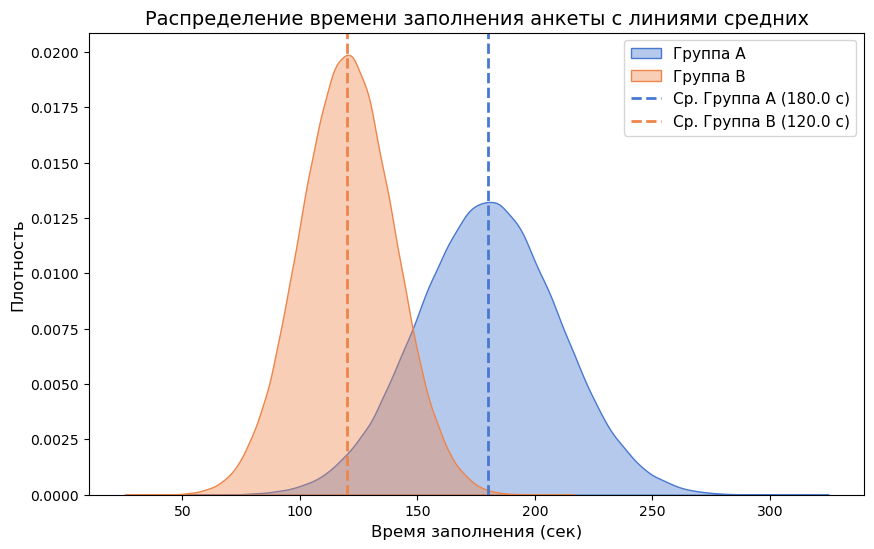

In [26]:
# Визуализация распределения времени
plt.figure(figsize=(10, 6))

# Настройка палитры «muted»
colors = sns.color_palette("muted")

# Отрисовка плотности
sns.kdeplot(data=df_base[df_base['variant'] == 'A'], x='time_to_complete', label='Группа А', fill=True, color=colors[0], alpha=0.4)
sns.kdeplot(data=df_base[df_base['variant'] == 'B'], x='time_to_complete', label='Группа B', fill=True, color=colors[1], alpha=0.4)

# Расчет средних
mean_A = df_base[df_base['variant'] == 'A']['time_to_complete'].mean()
mean_B = df_base[df_base['variant'] == 'B']['time_to_complete'].mean()

# Добавление вертикальных линий
plt.axvline(mean_A, color=colors[0], linestyle='--', linewidth=2, label=f'Ср. Группа А ({mean_A:.1f} с)')
plt.axvline(mean_B, color=colors[1], linestyle='--', linewidth=2, label=f'Ср. Группа B ({mean_B:.1f} с)')

plt.title('Распределение времени заполнения анкеты с линиями средних', fontsize=14)
plt.xlabel('Время заполнения (сек)', fontsize=12)
plt.ylabel('Плотность', fontsize=12)
plt.legend(fontsize=11)

plt.show()

In [27]:
# Статистический тест (Т-тест Уэлча)
time_a = df_base[df_base['variant'] == 'A']['time_to_complete'].dropna()
time_b = df_base[df_base['variant'] == 'B']['time_to_complete'].dropna()

pg.ttest(time_a, time_b)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,658.981205,264584.704179,two-sided,0.0,"[59.84, 60.2]",2.370136,inf,1.0


> **Вывод по времени:** Тест Уэлча подтвердил высокозначимое снижение времени заполнения в группе B со 180 до 120 секунд. Различия статистически значимы.

## 4. Сравнительный анализ долей (Конверсия и Риски)

In [28]:
# Анализ конверсии в отправку анкеты
expected_conv, observed_conv, stats_conv = pg.chi2_independence(df_base, x='is_submitted', y='variant')
stats_conv[stats_conv['test'] == 'pearson']

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,1330.231057,1.0,3.045418e-291,0.055077,1.0


In [29]:
# Анализ кредитных рисков / дефолтности портфеля
exp_risk, obs_risk, stats_risk = pg.chi2_independence(df_base, x='is_bad', y='variant')
stats_risk[stats_risk['test'] == 'pearson']

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.0,2.043565,1.0,0.152851,0.002159,0.298257


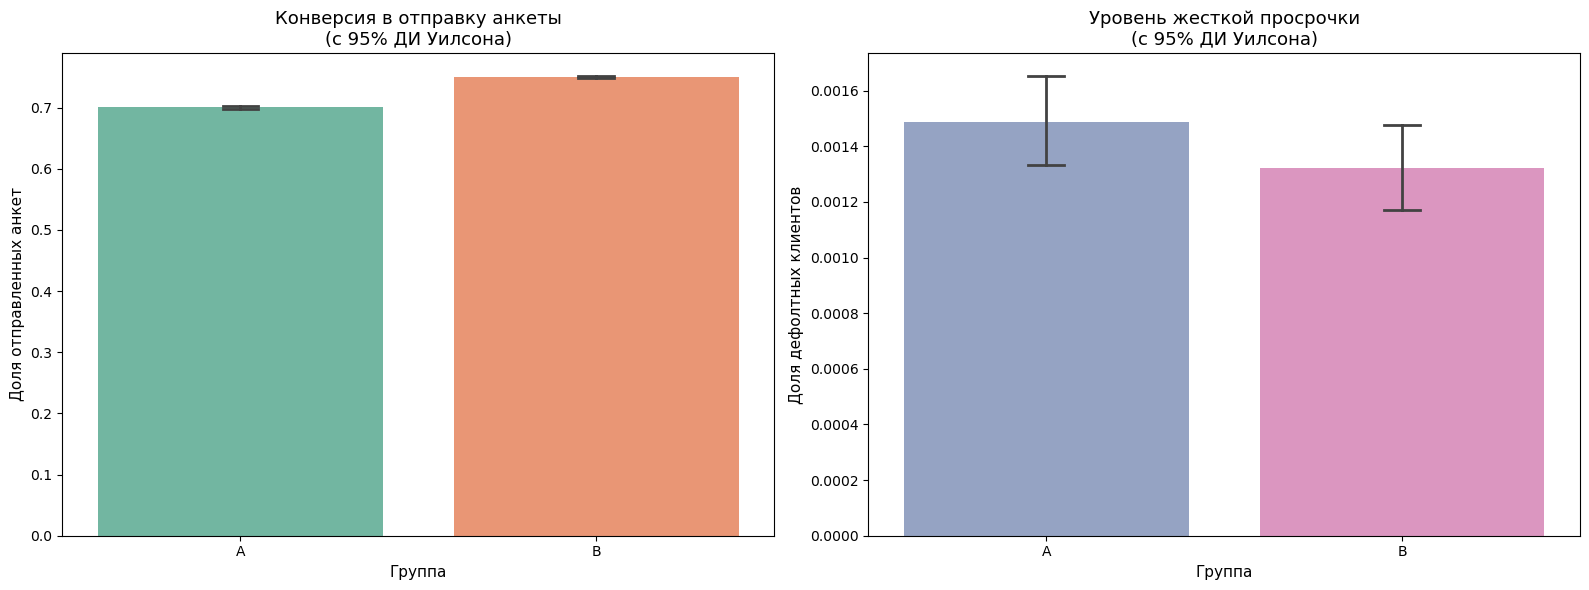

In [30]:
# Построение графиков с Доверительными интервалами
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Используем палитру Set2
palette_colors = sns.color_palette("Set2")

# График Конверсии
sns.barplot(
    data=df_base, x='variant', y='is_submitted', hue='variant', ax=axes[0], 
    palette=palette_colors[:2], errorbar=('ci', 95), capsize=0.1, err_kws={'linewidth': 2}, legend=False
)
axes[0].set_title('Конверсия в отправку анкеты\n(с 95% ДИ Уилсона)', fontsize=13)
axes[0].set_xlabel('Группа', fontsize=11)
axes[0].set_ylabel('Доля отправленных анкет', fontsize=11)

# График Кредитных Рисков
sns.barplot(
    data=df_base, x='variant', y='is_bad', hue='variant', ax=axes[1], 
    palette=palette_colors[2:4], errorbar=('ci', 95), capsize=0.1, err_kws={'linewidth': 2}, legend=False
)
axes[1].set_title('Уровень жесткой просрочки\n(с 95% ДИ Уилсона)', fontsize=13)
axes[1].set_xlabel('Группа', fontsize=11)
axes[1].set_ylabel('Доля дефолтных клиентов', fontsize=11)

plt.tight_layout()
plt.show()

## Итоговое аналитическое заключение
1. **Скорость работы:** Новый дизайн (Вариант B) сократил время заполнения анкеты со 180 до 120 секунд. Сдвиг распределения статистически значим ($p < 0.05$, Т-тест Уэлча).
2. **Конверсия:** Доля успешно отправленных анкет в группе B значимо выросла ($p < 0.05$, Хи-квадрат). Изменение интерфейса снизило отток пользователей.
3. **Кредитные риски:** Различия в уровне дефолтности (`is_bad`) между группами статистически НЕ значимы ($p = 0.153$, Хи-квадрат). Упрощение анкеты не ухудшило качество входящего потока клиентов.

**Рекомендация для бизнеса:** Эксперимент признан успешным. Рекомендуется полностью раскатить Вариант B на 100% пользователей.